In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
df = pd.read_csv('gym_raw.csv')
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (4000, 15)


,customer _ID,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Months_to_end_contract,Lifetime_in_the _gym,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,GYM_0001,Male,Near,Yes,Yes,No,6,Attends,29,14.227470,5,3,0.020398,0.000000,Stayed
1,GYM_0002,Female,Near,No,No,Yes,12,Attends,31,113.202938,12,7,1.922936,1.910244,Stayed
2,GYM_0003,Female,Near,Yes,No,Yes,1,Solo,28,129.448479,1,2,1.859098,1.736502,Stayed
3,GYM_0004,Female,Near,Yes,Yes,Yes,12,Attends,33,62.669863,12,2,3.205633,3.357215,Stayed
4,GYM_0005,Male,Near,Yes,Yes,Yes,1,Solo,26,198.362265,1,3,1.113884,1.120078,Stayed


In [32]:
print("Dataset Info:")
df.info()

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:")
display(df.describe())

# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicates}")

# Unique values in categorical columns
df.select_dtypes('object').nunique()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 15 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   customer _ID                       4000 non-null   object 
 1   gender                             4000 non-null   object 
 2   Near_Location                      4000 non-null   object 
 3   Partner                            4000 non-null   object 
 4   Promo_friends                      4000 non-null   object 
 5   Phone                              4000 non-null   object 
 6   Contract_period                    4000 non-null   int64  
 7   Group_visits                       4000 non-null   object 
 8   Age                                4000 non-null   int64  
 9   Avg_additional_charges_total       4000 non-null   float64
 10  Months_to_end_contract             4000 non-null   int64  
 11  Lifetime_in_the _gym               4000 no

,Contract_period,Age,Avg_additional_charges_total,Months_to_end_contract,Lifetime_in_the _gym,Avg_class_frequency_total,Avg_class_frequency_current_month
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,4.681250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052
std,4.549706,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906
min,1.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000
25%,1.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003
50%,1.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574
75%,6.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336
max,12.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783



Duplicate Rows: 0


customer _ID     4000
gender              2
Near_Location       2
Partner             2
Promo_friends       2
Phone               2
Group_visits        2
Churn               2
dtype: int64

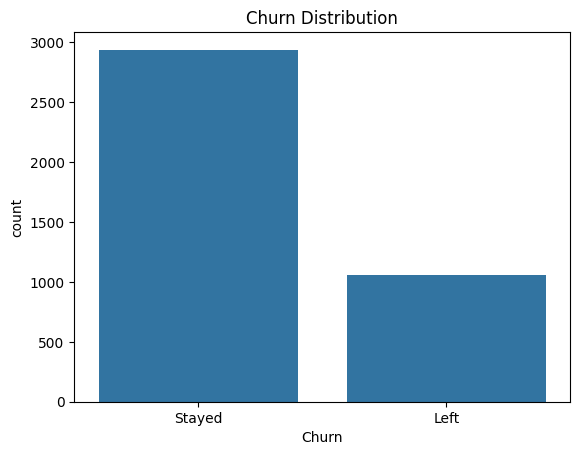

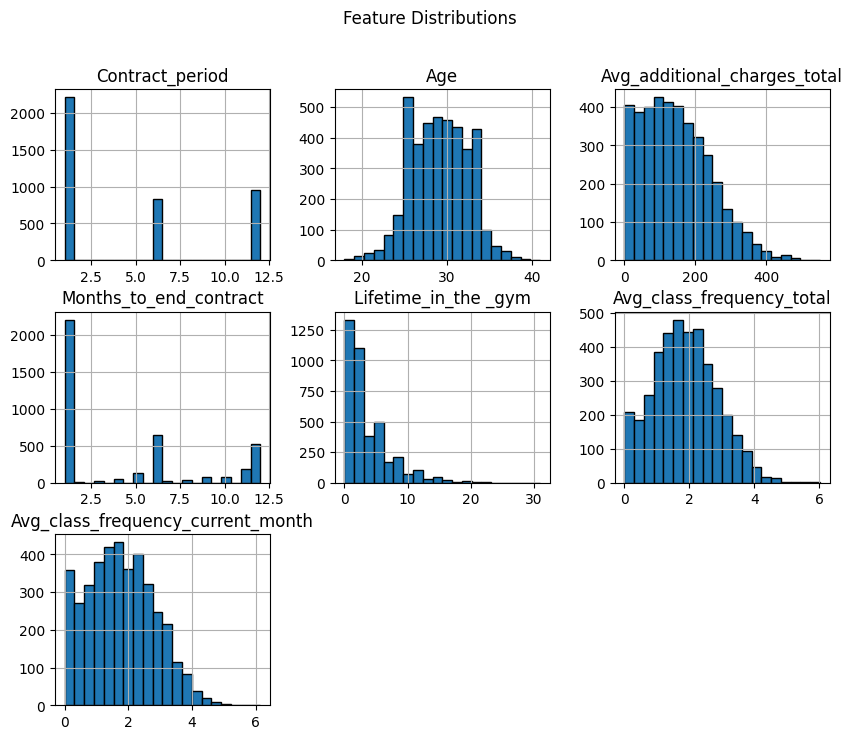

In [33]:
# Distribution of churn
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

# Histograms for numeric columns
df.hist(figsize=(10,8), bins=20, edgecolor='black')
plt.suptitle("Feature Distributions")
plt.show()


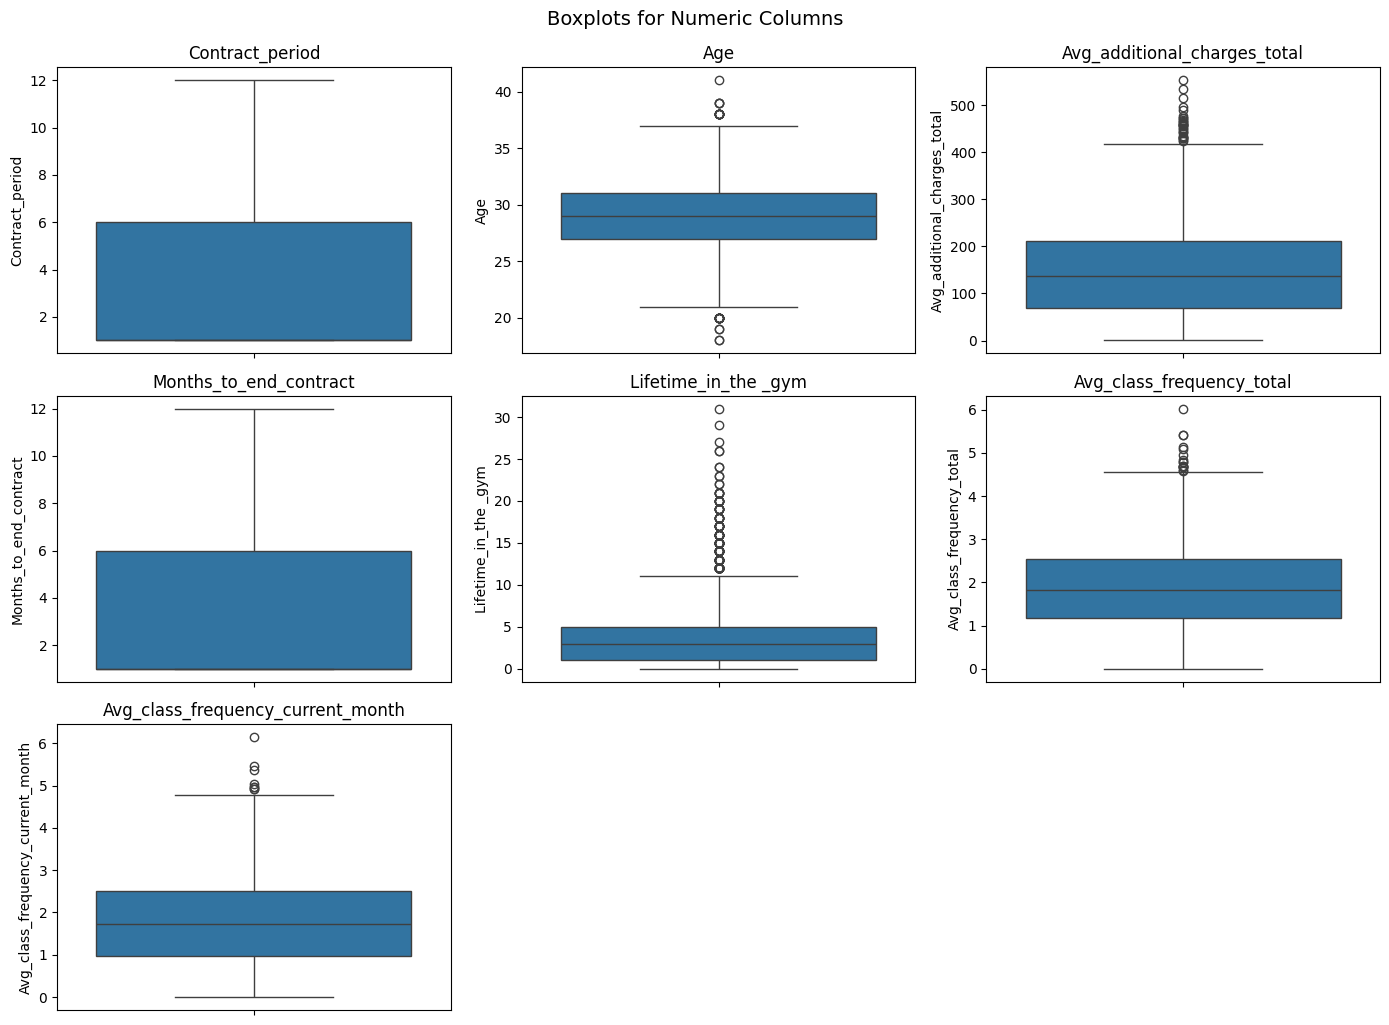

In [34]:
# Boxplots for all numeric columns in a grid layout
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(14, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)  # adjust grid size (rows, cols)
    sns.boxplot(y=df[col])
    plt.title(col)
    plt.tight_layout()

plt.suptitle("Boxplots for Numeric Columns", fontsize=14, y=1.02)
plt.show()


### Correlation Test

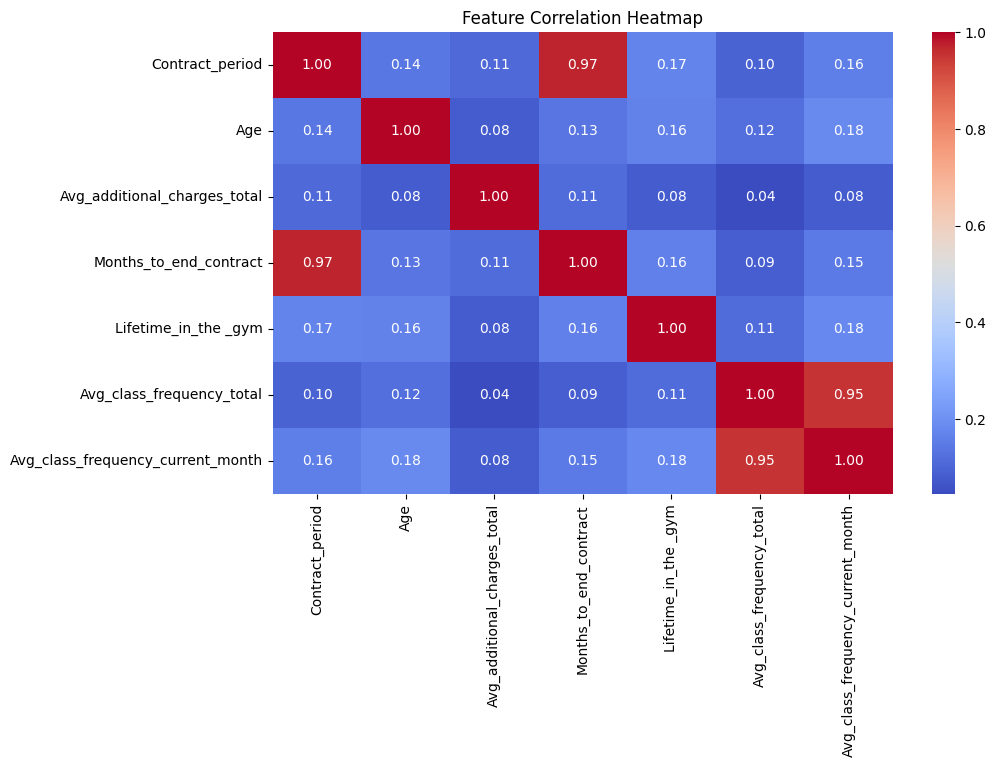

In [36]:
# Correlation heatmap for numeric columns
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include=['int64', 'float64']).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


| Feature Pair                                                      | Correlation   | Interpretation                                                                                                                                                                                               |
| ----------------------------------------------------------------- | ------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **Contract_period ↔ Months_to_end_contract**                      | **0.97**      | Extremely strong positive correlation. Longer contracts naturally mean more months left before expiry. These two features carry nearly the same information (you could drop one to avoid multicollinearity). |
| **Avg_class_frequency_total ↔ Avg_class_frequency_current_month** | **0.95**      | Very strong positive correlation. A customer’s long-term class frequency aligns closely with their recent activity. Again, consider keeping only one.                                                        |
| **Contract_period ↔ Lifetime_in_the_gym**                         | **0.17**      | Weak positive correlation — people with longer contracts might have been members longer, but not strongly so.                                                                                                |
| **Age ↔ Other Variables**                                         | **0.08–0.18** | Weak correlation — age doesn’t strongly relate to contract, spending, or activity patterns.                                                                                                                  |
| **Avg_additional_charges_total ↔ Others**                         | **≈0.1**      | Minimal correlation — extra spending isn’t tightly linked to other features.                                                                                                                                 |


| Highly Correlated Pair                                            | Keep                                  | Drop                          | Reason                                                                              |
| ----------------------------------------------------------------- | ------------------------------------- | ----------------------------- | ----------------------------------------------------------------------------------- |
| `Contract_period` ↔ `Months_to_end_contract`                      | ✅ `Contract_period`                   | ❌ `Months_to_end_contract`    | They represent the same concept. Keeping `Contract_period` is simpler.              |
| `Avg_class_frequency_total` ↔ `Avg_class_frequency_current_month` | ✅ `Avg_class_frequency_current_month` | ❌ `Avg_class_frequency_total` | Recent activity (current month) is more predictive of churn than long-term average. |


In [37]:
# Drop highly correlated features
df_reduced = df.drop(columns=['Months_to_end_contract', 'Avg_class_frequency_total',"customer _ID"])

# Verify shape
print("Original shape:", df.shape)
print("Reduced shape:", df_reduced.shape)


Original shape: (4000, 15)
Reduced shape: (4000, 12)


### Numerical Feature Correlations with Churn

Correlation of each numeric feature with Churn:

                                      Churn
Churn                              1.000000
Avg_additional_charges_total      -0.198697
Avg_class_frequency_total         -0.249715
Months_to_end_contract            -0.381393
Contract_period                   -0.389984
Age                               -0.404735
Avg_class_frequency_current_month -0.412348
Lifetime_in_the _gym              -0.438220


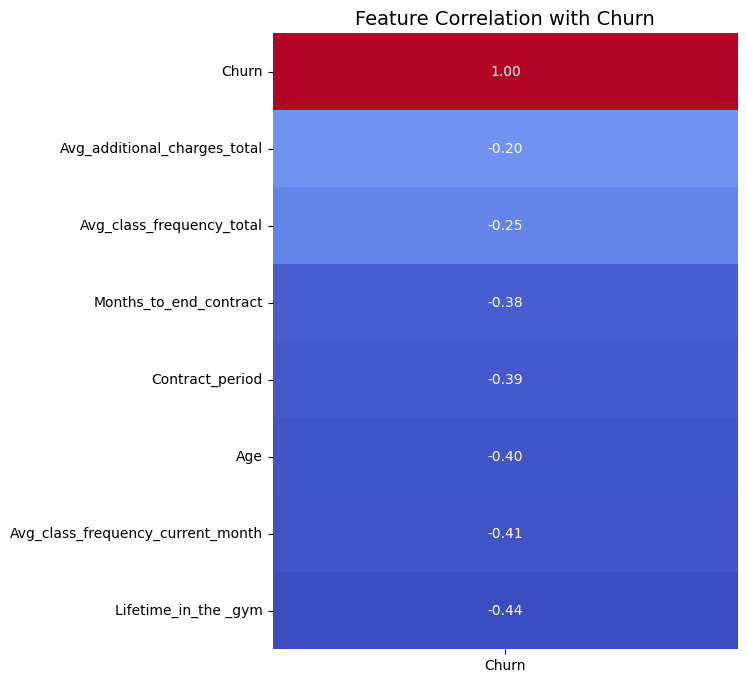

In [ ]:
# Clean column names
df.columns = df.columns.str.strip()

# Convert Churn column to numeric (left/stayed → 1/0)
df['Churn'] = df['Churn'].map({'Stayed': 0, 'Left': 1, True: 1, False: 0}).astype('int')

# Now select numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation with Churn
corr_with_churn = numeric_df.corr()[['Churn']].sort_values(by='Churn', ascending=False)

# Display correlation values
print("Correlation of each numeric feature with Churn:\n")
print(corr_with_churn)

# Visualize correlation with Churn
plt.figure(figsize=(6, 8))
sns.heatmap(corr_with_churn, annot=True, cmap='coolwarm', fmt='.2f', cbar=False)
plt.title('Feature Correlation with Churn', fontsize=14)
plt.show()


| **Predictor**                         | **Correlation with Churn** | **Interpretation (assuming Churn = 1 means they left)**                                                                 |
| ------------------------------------- | -------------------------- | ----------------------------------------------------------------------------------------------------------------------- |
| **Lifetime_in_the_gym**               | -0.438                     | The longer someone has been a gym member, the less likely they are to leave. Loyal, long-term members tend to stay.     |
| **Avg_class_frequency_current_month** | -0.412                     | Members attending more classes this month are less likely to leave — engagement predicts retention.                     |
| **Age**                               | -0.405                     | Older members are slightly more likely to stay than younger ones.                                                       |
| **Contract_period**                   | -0.390                     | Longer contracts are linked with lower churn — commitment helps retention.                                              |
| **Months_to_end_contract**            | -0.381                     | Members with more months remaining on their contracts are less likely to leave.                                         |
| **Avg_class_frequency_total**         | -0.250                     | Overall class participation frequency is negatively correlated with churn — consistent participation indicates loyalty. |
| **Avg_additional_charges_total**      | -0.199                     | Members who spend more on extras (like merch or private sessions) are less likely to leave.                             |
| **Churn**                             | 1.000                      | Perfect correlation with itself (baseline).                                                                             |


### Categorical Feature Correlations with Churn

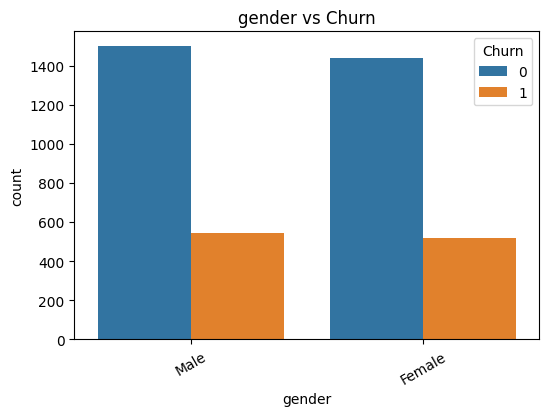

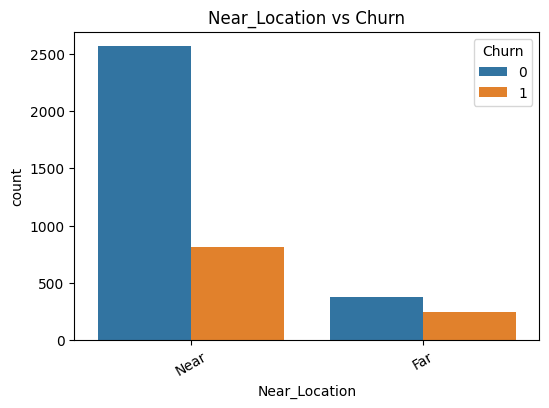

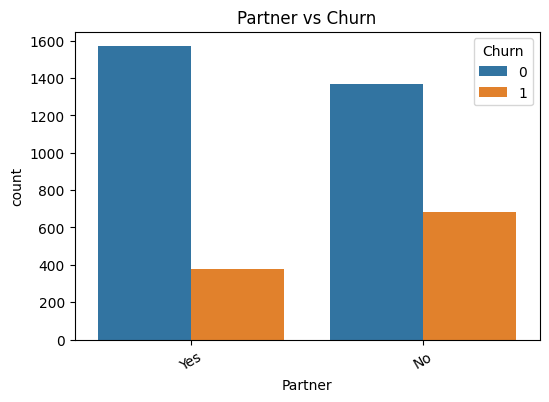

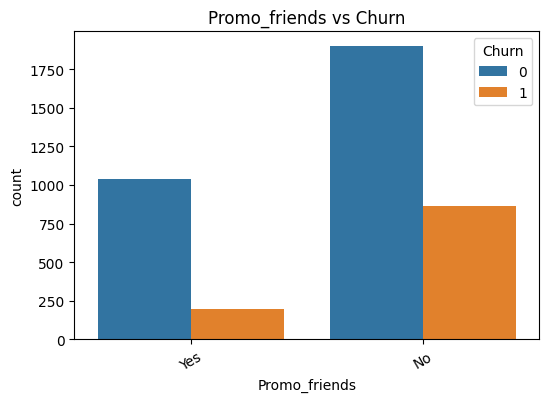

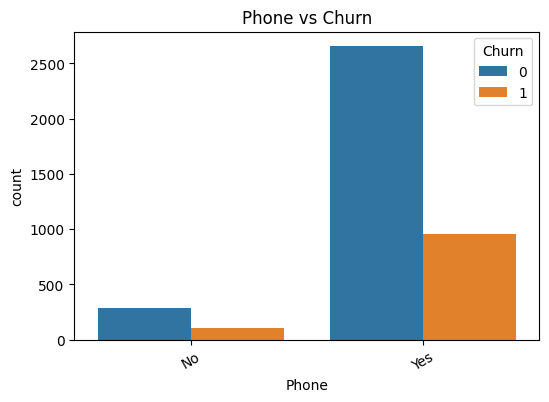

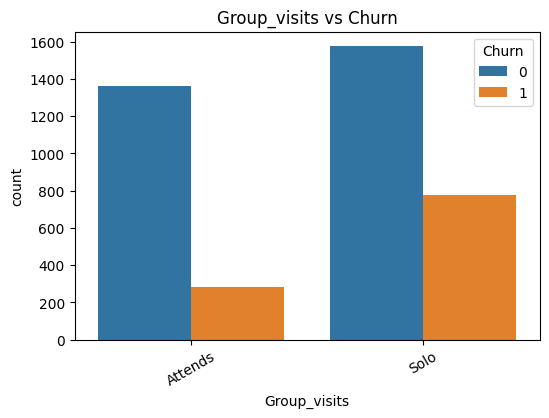

In [39]:
# Bar plots for categorical features vs churn
categorical_cols = ['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone', 'Group_visits']

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, hue='Churn', data=df)
    plt.title(f"{col} vs Churn")
    plt.xticks(rotation=30)
    plt.show()


| **Feature**       | **Observation**                                                                             | **Interpretation**                                                            |
| ----------------- | ------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------- |
| **Gender**        | Both male and female customers show similar retention patterns; slightly more males stayed. | ➤ Little to no effect on churn.                                               |
| **Near_Location** | Customers living near the gym are far more likely to stay; those far show higher churn.     | ➤ Proximity is an important retention factor.                                 |
| **Group_visits**  | Customers attending group visits have much lower churn than solo visitors.                  | ➤ Strong influence  — social/group participation boosts retention. |
| **Phone**         | Most customers have a phone; churn rates within this group align with overall averages.     | ➤ Weak influence — mainly reflects the customer base composition.             |
| **Promo_friends** | Customers acquired via friend promotions or referrals show much lower churn.                | ➤ Strong influence — social referral drives loyalty.                 |
| **Partner**       | Customers with a partner have slightly better retention than those without.                 | ➤ Moderate influence — relationship support may help sustain engagement.      |


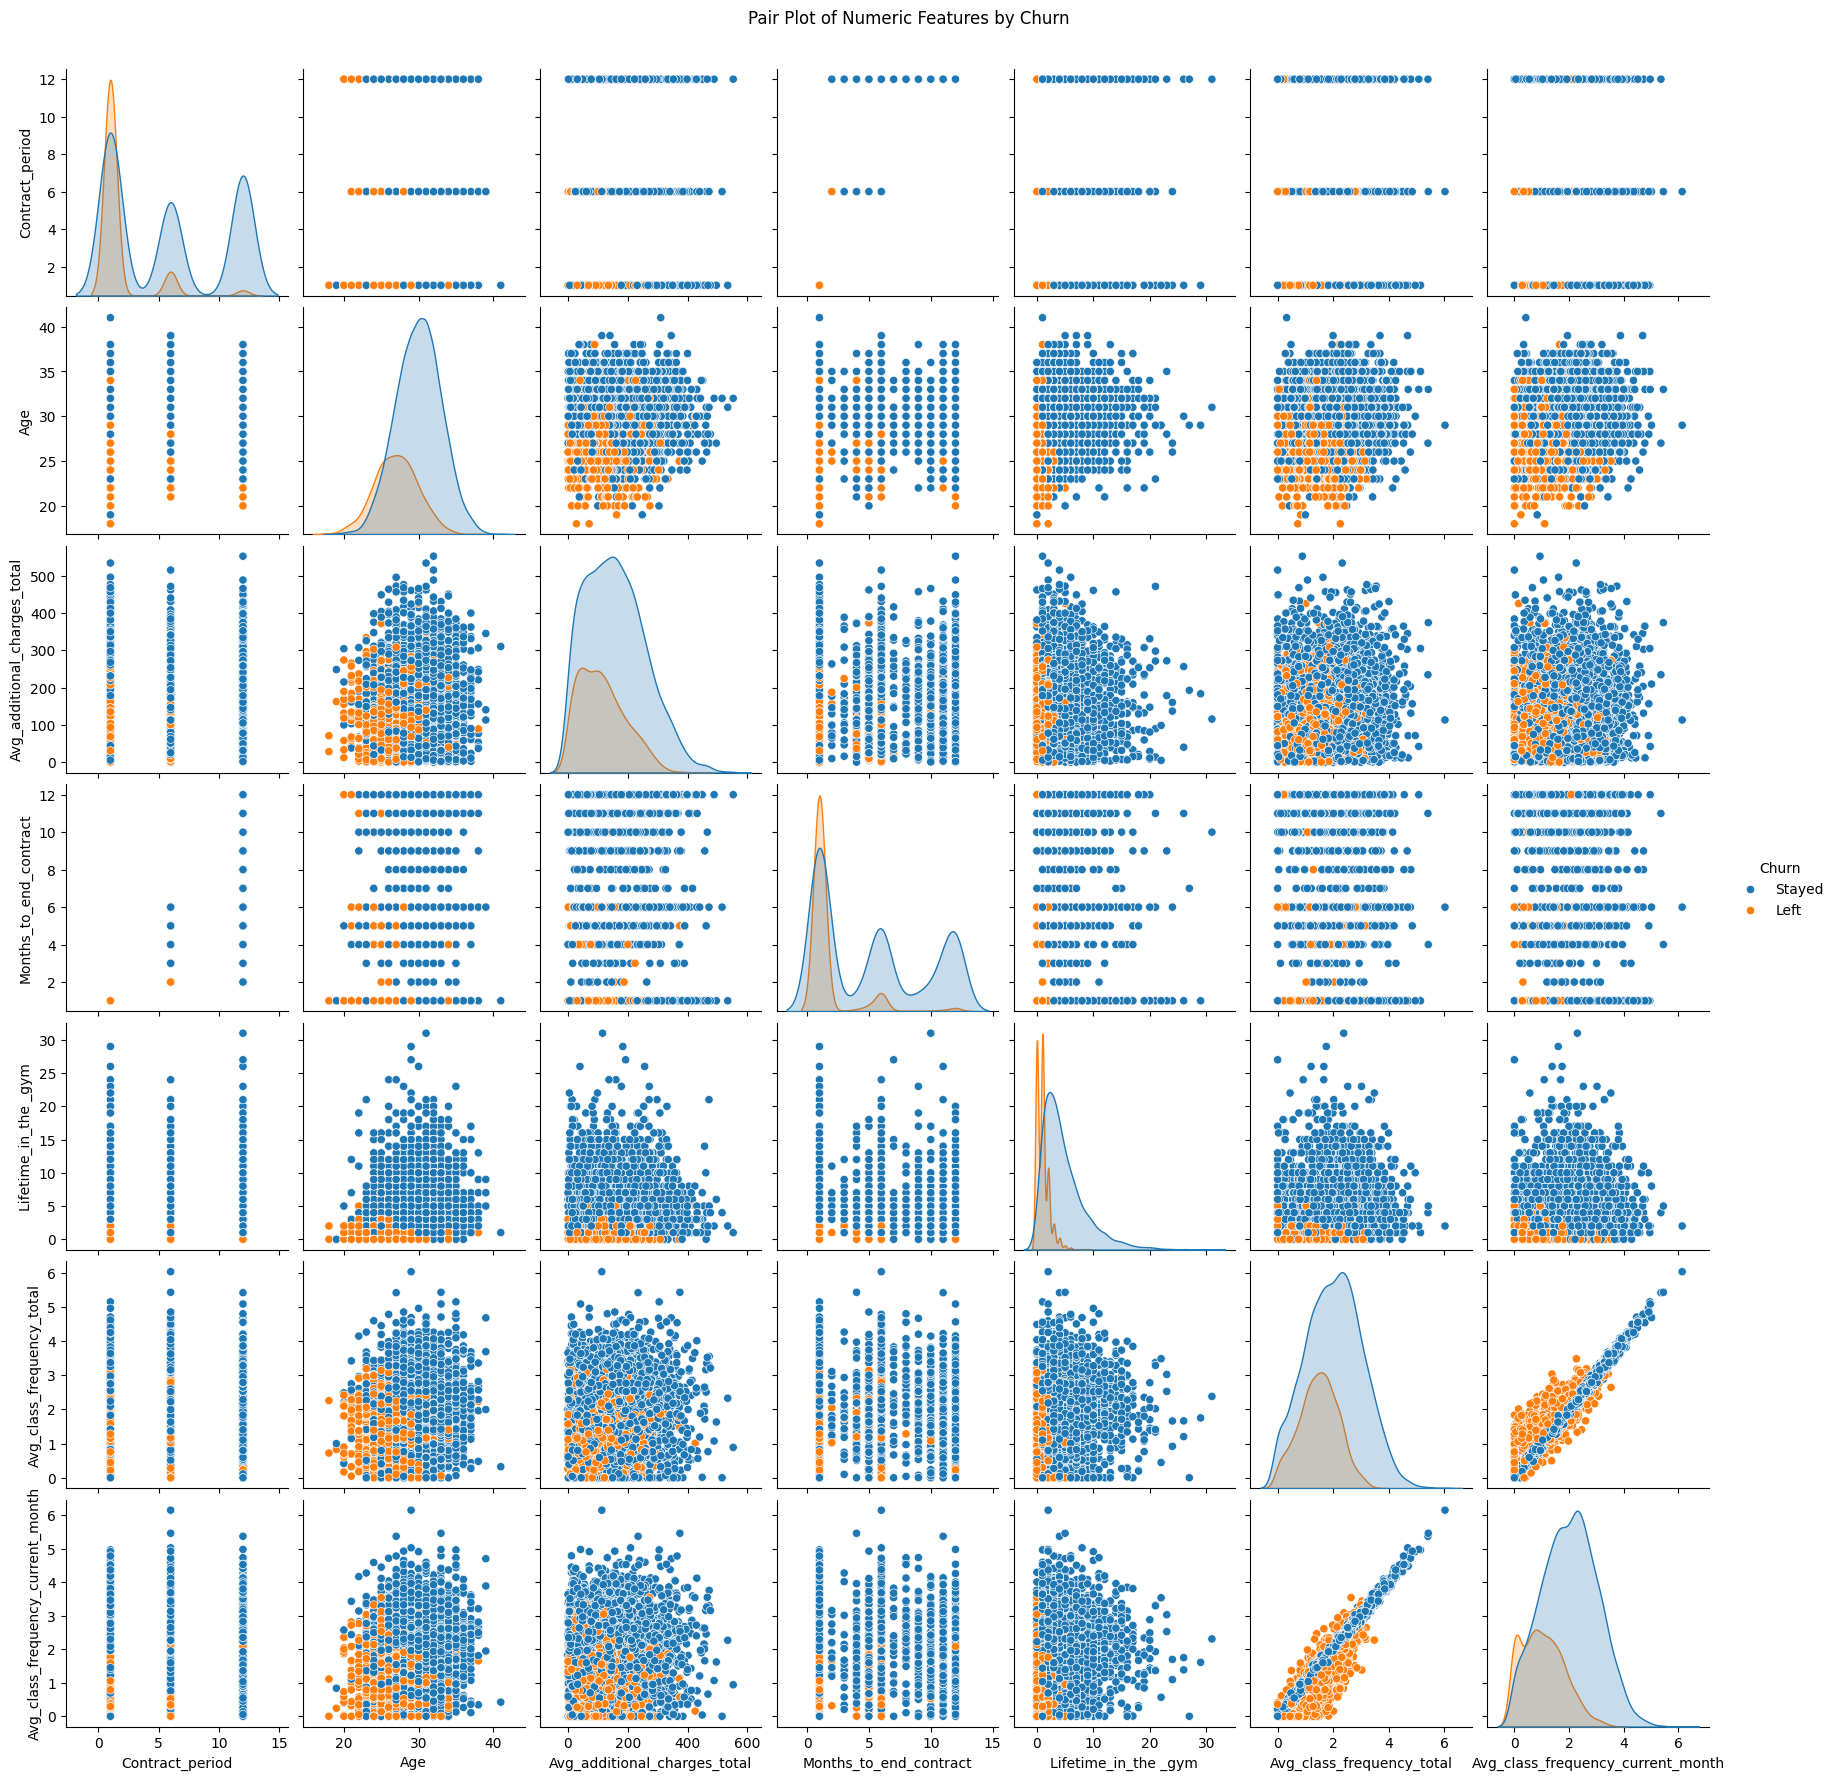

In [44]:
# Pair plot for numeric columns colored by Churn
sns.pairplot(df, vars=df.select_dtypes(include=['int64', 'float64']).columns, hue='Churn', diag_kind='kde')
plt.suptitle("Pair Plot of Numeric Features by Churn", y=1.02)
plt.show()


### The diagonal 

| Variable                              | Distribution Shape                                           | Key Insights                                                                                                        |
| ------------------------------------- | ------------------------------------------------------------ | ------------------------------------------------------------------------------------------------------------------- |
| **Contract_period**                   | Distinct peaks at fixed durations (e.g., 1, 3, 6, 12 months) | Members with **longer contracts** are more likely to stay, while short-term contracts show higher churn.            |
| **Age**                               | Bell-shaped, mostly 25–35 years                              | Age does not strongly separate churn groups, though churn appears slightly higher among younger members.            |
| **Avg_additional_charges_total**      | Right-skewed (most pay little, few pay much more)            | Members who spend more on additional services are **less likely to churn**, indicating higher engagement.           |
| **Months_to_end_contract**            | Multiple peaks (based on contract length)                    | Churners are concentrated near the **start or end** of contracts, suggesting cancellations early or before renewal. |
| **Lifetime_in_the_gym**               | Strongly right-skewed                                        | Shorter gym lifetimes are associated with higher churn, while long-term members tend to stay.                       |
| **Avg_class_frequency_total**         | Right-skewed                                                 | Members who attend classes more frequently show **lower churn rates**.                                              |
| **Avg_class_frequency_current_month** | Right-skewed                                                 | Recent class participation is a strong retention indicator — low activity often precedes churn.                     |


2. Relationships Between Features (Off-Diagonal)

The off-diagonal scatterplots show pairwise relationships between the numeric variables:

Lifetime_in_the_gym vs. Class Frequencies:
Strong positive correlation — long-term members tend to attend more classes.

Contract_period vs. Months_to_end_contract:
Positive relationship, as expected for fixed contract structures.

Churn Patterns:
Orange points (churners) cluster in areas of low engagement — shorter gym lifetime, fewer classes, lower additional charges, and shorter contracts.

Key Takeaways

Engagement metrics (Avg_class_frequency_total, Avg_class_frequency_current_month, and Lifetime_in_the_gym) are strong predictors of retention.

Contract-related variables (Contract_period, Months_to_end_contract) also influence churn — longer and ongoing contracts reduce churn likelihood.

Spending on add-ons (Avg_additional_charges_total) correlates with loyalty — high-spending members are typically more engaged.

Age has minimal predictive power compared to behavioral features.

4. Conclusion and Modeling Implications

From the EDA, it is evident that behavioral and engagement-based features are the most influential in determining churn.
For churn prediction modeling, the following features should be prioritized:

Contract characteristics: Contract_period, Months_to_end_contract

Engagement activity: Lifetime_in_the_gym, Avg_class_frequency_total, Avg_class_frequency_current_month

Spending behavior: Avg_additional_charges_total

These features capture customer commitment, activity, and loyalty, making them powerful predictors for a classification model.
Demographic variables like Age may still be included but likely contribute less explanatory power.

### Not linearly Separable.
#### Non-linear models such as Random Forests, Gradient Boosting, or Neural Networks are likely to perform better in distinguishing churn behavior.